Using device: cuda
Train clean: 2000 | Val clean: 400
Train noisy: 2000 | Val noisy: 400


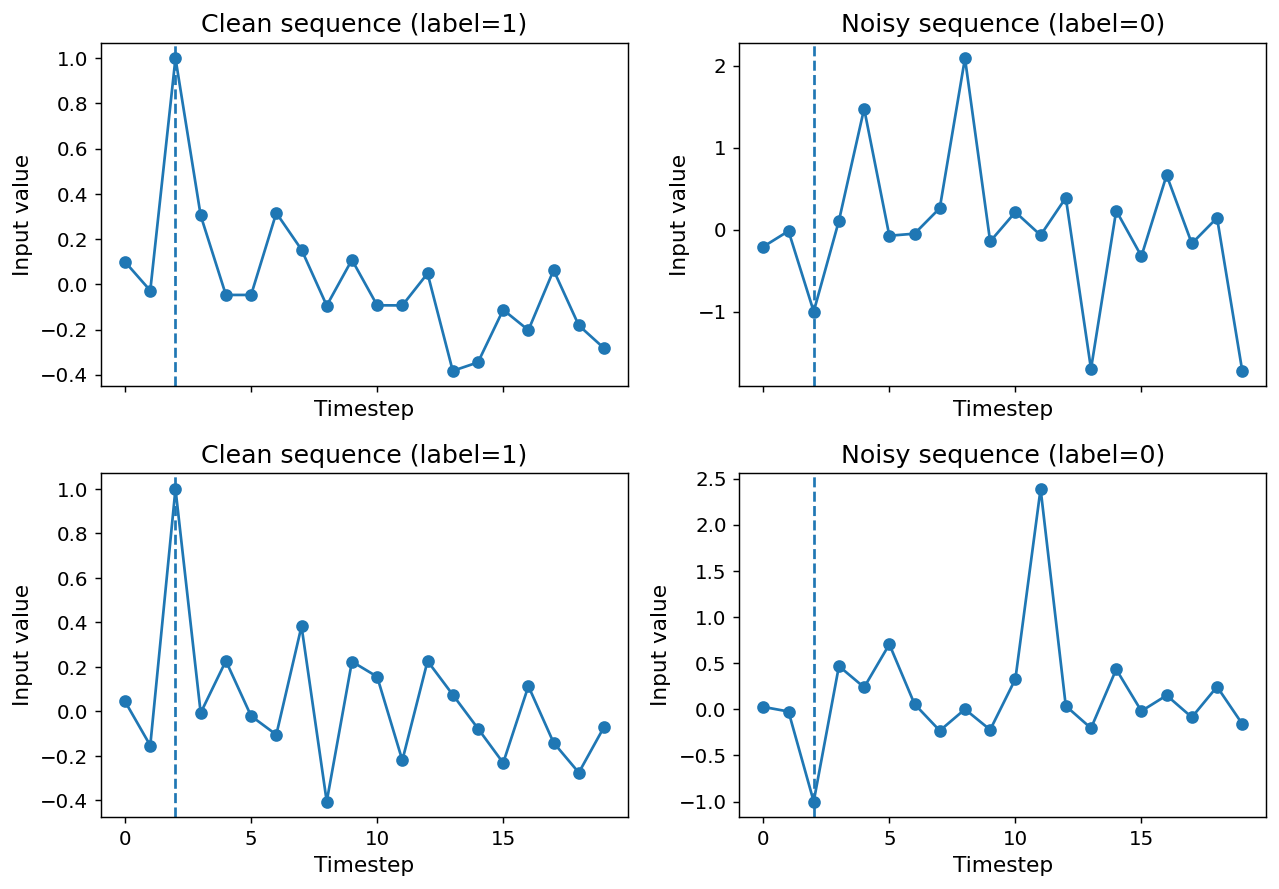


Training clean model...
Epoch 01 | train_loss=0.6994 | train_acc=0.4985 | val_loss=0.6876 | val_acc=0.5450
Epoch 02 | train_loss=0.6889 | train_acc=0.5365 | val_loss=0.6558 | val_acc=0.9050
Epoch 03 | train_loss=0.2547 | train_acc=0.9605 | val_loss=0.0361 | val_acc=0.9900
Epoch 04 | train_loss=0.0092 | train_acc=0.9985 | val_loss=0.0017 | val_acc=1.0000
Epoch 05 | train_loss=0.0039 | train_acc=0.9990 | val_loss=0.0014 | val_acc=1.0000
Epoch 06 | train_loss=0.0041 | train_acc=0.9995 | val_loss=0.0011 | val_acc=1.0000
Epoch 07 | train_loss=0.0009 | train_acc=1.0000 | val_loss=0.0007 | val_acc=1.0000
Epoch 08 | train_loss=0.0006 | train_acc=1.0000 | val_loss=0.0005 | val_acc=1.0000
Epoch 09 | train_loss=0.0005 | train_acc=1.0000 | val_loss=0.0004 | val_acc=1.0000
Epoch 10 | train_loss=0.0004 | train_acc=1.0000 | val_loss=0.0003 | val_acc=1.0000
Epoch 11 | train_loss=0.0003 | train_acc=1.0000 | val_loss=0.0003 | val_acc=1.0000
Epoch 12 | train_loss=0.0003 | train_acc=1.0000 | val_loss=0.0

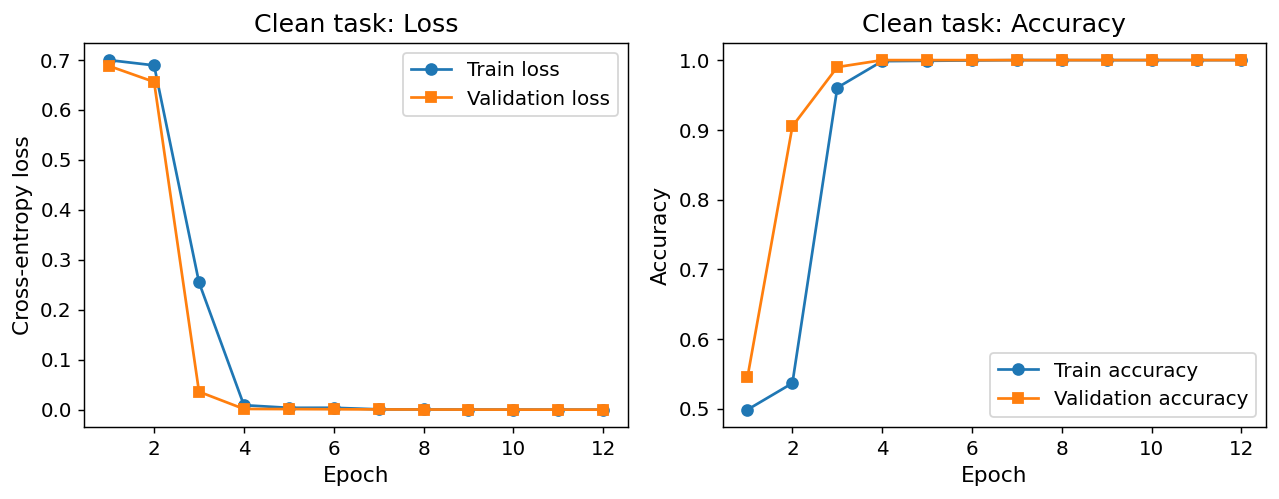

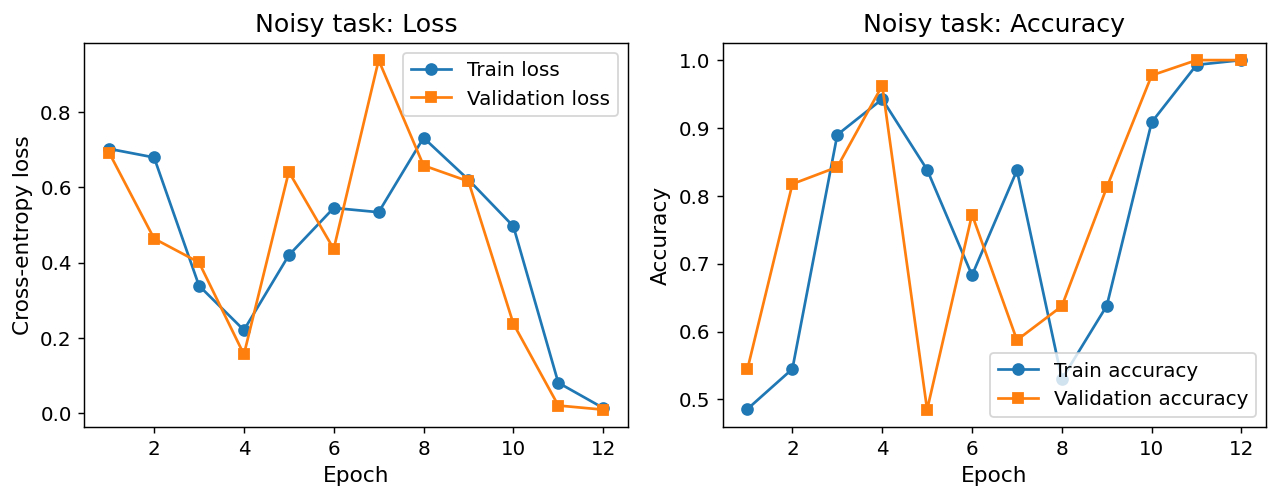

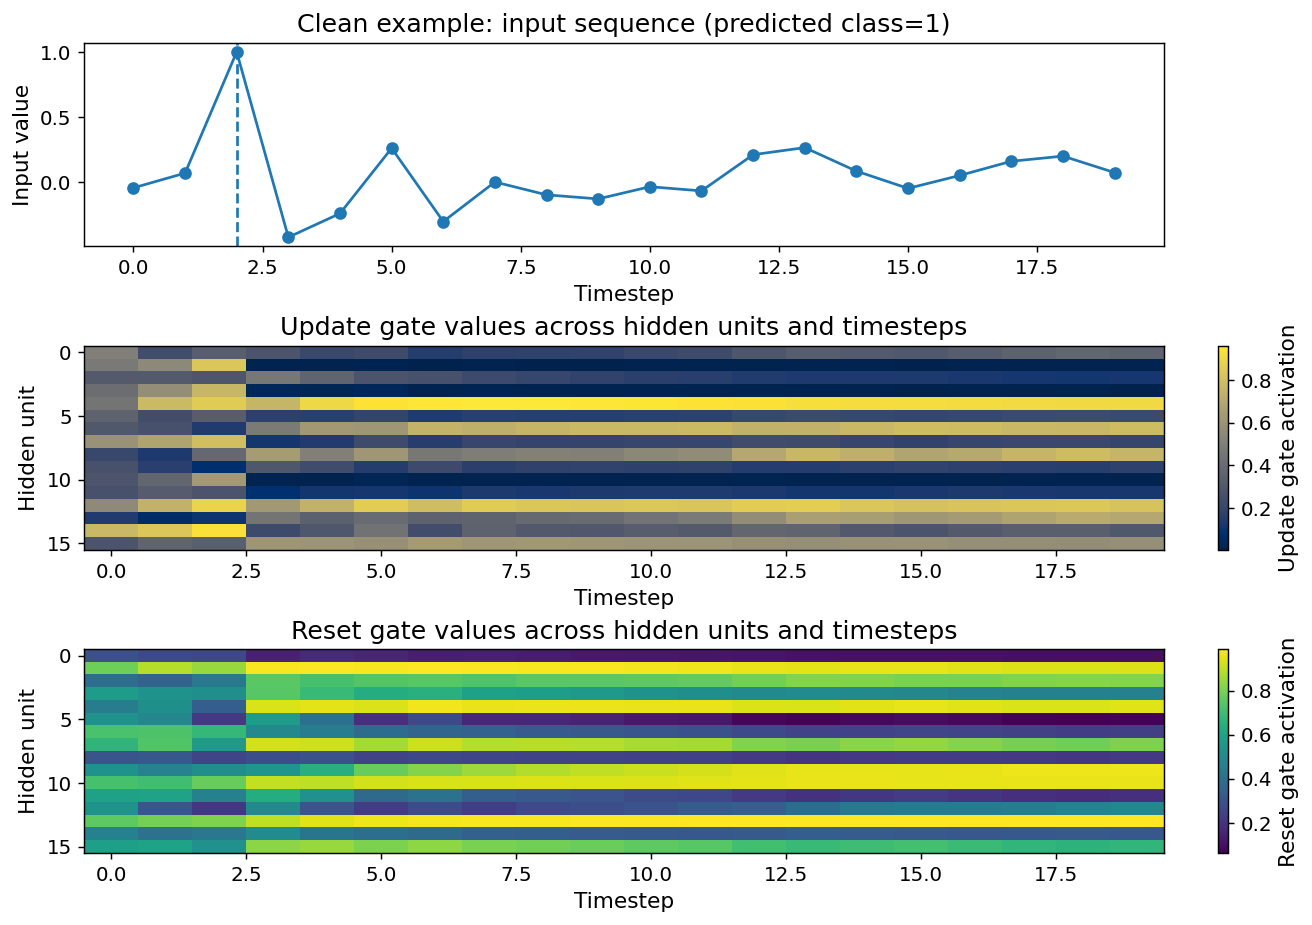

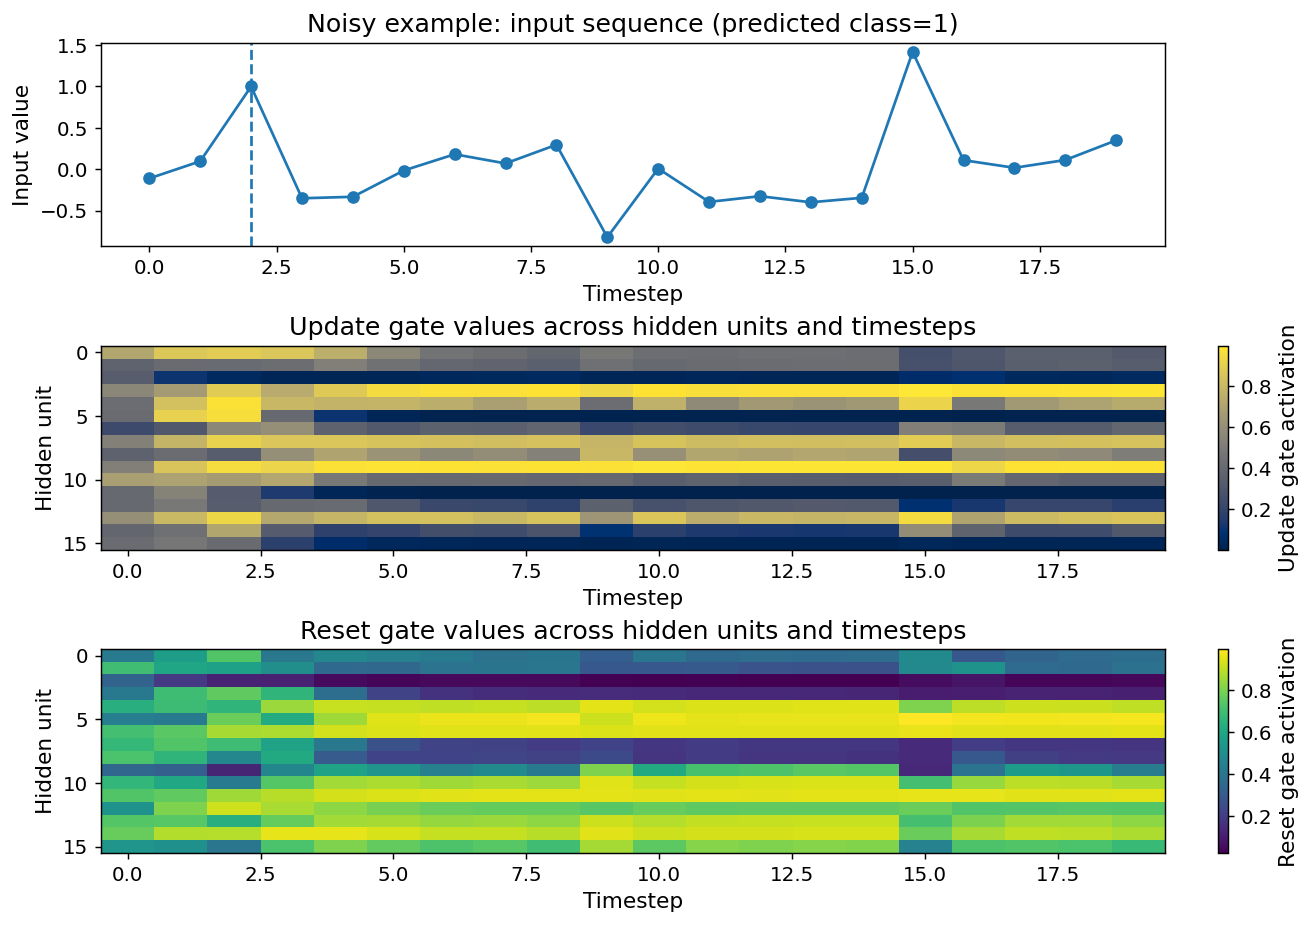

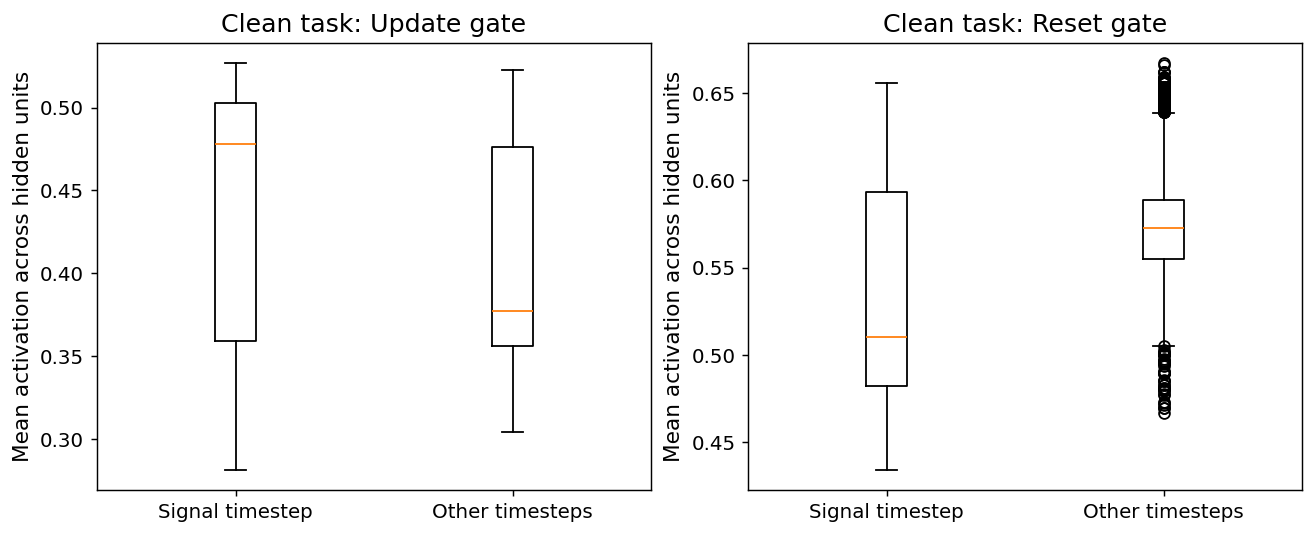

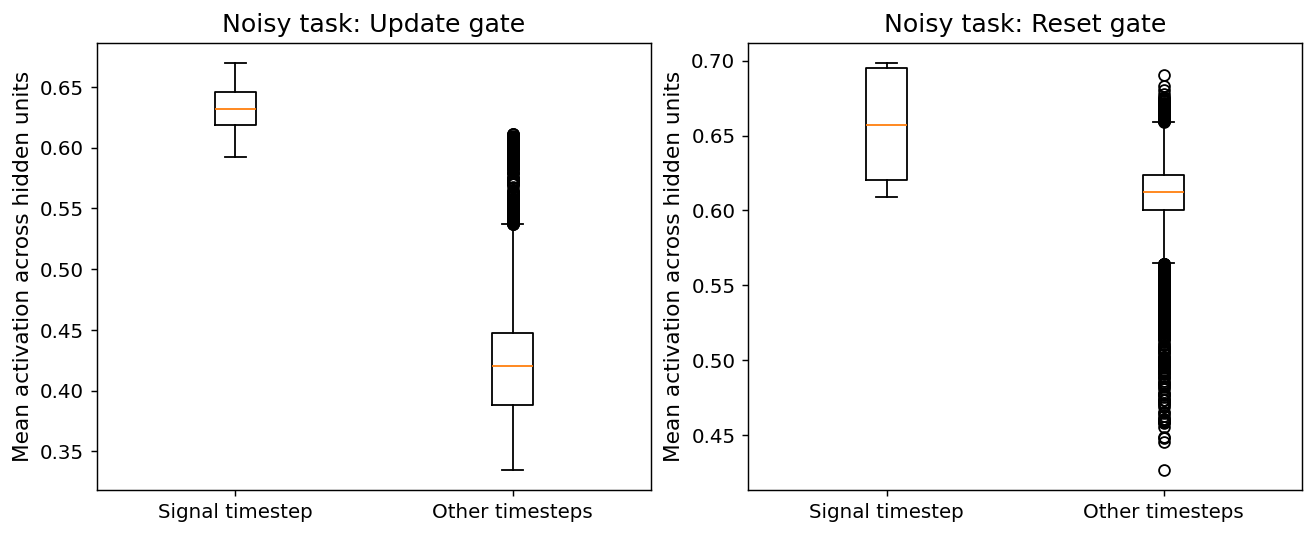


Clean task gate summary
-----------------------
Mean update gate at signal timestep: 0.4344
Mean update gate at other timesteps: 0.4060
Mean reset gate at signal timestep:  0.5350
Mean reset gate at other timesteps:  0.5735

Noisy task gate summary
-----------------------
Mean update gate at signal timestep: 0.6318
Mean update gate at other timesteps: 0.4308
Mean reset gate at signal timestep:  0.6573
Mean reset gate at other timesteps:  0.6086

Done. All figures and summaries generated.


In [1]:
# ============================================================
# FULL GRU GATE INTERPRETATION NOTEBOOK IN ONE CELL
# Topic: Interpreting GRU Gates: What Does the Model Actually Remember?
# ============================================================

# ---------------------------
# 1. IMPORTS + SETUP
# ---------------------------
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Accessibility-friendly plotting defaults
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 130
})

# ---------------------------
# 2. SYNTHETIC DATASET
# ---------------------------
class MemorySequenceDataset(Dataset):
    """
    Synthetic sequence classification task.

    Each sequence contains:
    - mostly low-amplitude noise
    - one informative signal at a fixed early timestep
    - the class label depends only on that signal
    - optionally stronger distractor noise later in the sequence

    This setup is useful because we know exactly which timestep
    the model should remember.
    """
    def __init__(self, n_samples=2000, seq_len=20, input_dim=1, signal_pos=2, noisy=False):
        self.n_samples = n_samples
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.signal_pos = signal_pos
        self.noisy = noisy
        self.X, self.y = self._generate()

    def _generate(self):
        X = []
        y = []

        for _ in range(self.n_samples):
            # Base sequence: small random fluctuations
            seq = np.random.normal(loc=0.0, scale=0.2, size=(self.seq_len, self.input_dim))

            # Informative marker determines the label
            label = np.random.randint(0, 2)
            informative_value = 1.0 if label == 1 else -1.0
            seq[self.signal_pos, 0] = informative_value

            # Add stronger distractor noise later in the sequence
            if self.noisy:
                noise_positions = list(range(self.signal_pos + 2, self.seq_len))
                chosen = np.random.choice(
                    noise_positions,
                    size=max(2, self.seq_len // 4),
                    replace=False
                )
                seq[chosen, 0] += np.random.normal(0, 1.2, size=len(chosen))

            X.append(seq.astype(np.float32))
            y.append(label)

        return torch.tensor(np.stack(X)), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ---------------------------
# 3. CREATE DATASETS + LOADERS
# ---------------------------
seq_len = 20
signal_pos = 2
batch_size = 64

train_clean = MemorySequenceDataset(
    n_samples=2000, seq_len=seq_len, signal_pos=signal_pos, noisy=False
)
val_clean = MemorySequenceDataset(
    n_samples=400, seq_len=seq_len, signal_pos=signal_pos, noisy=False
)

train_noisy = MemorySequenceDataset(
    n_samples=2000, seq_len=seq_len, signal_pos=signal_pos, noisy=True
)
val_noisy = MemorySequenceDataset(
    n_samples=400, seq_len=seq_len, signal_pos=signal_pos, noisy=True
)

train_loader = DataLoader(train_clean, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_clean, batch_size=batch_size)

train_loader_noisy = DataLoader(train_noisy, batch_size=batch_size, shuffle=True)
val_loader_noisy = DataLoader(val_noisy, batch_size=batch_size)

print("Train clean:", len(train_clean), "| Val clean:", len(val_clean))
print("Train noisy:", len(train_noisy), "| Val noisy:", len(val_noisy))

# ---------------------------
# 4. SAMPLE SEQUENCE VISUALISATION
# ---------------------------
def plot_sample_sequences(clean_ds, noisy_ds, signal_pos=2, n_examples=2):
    """
    Plot a few example sequences from the clean and noisy datasets.
    The dashed vertical line marks the informative timestep.
    """
    fig, axes = plt.subplots(n_examples, 2, figsize=(10, 3.5 * n_examples), sharex=True)

    if n_examples == 1:
        axes = np.array([axes])

    for i in range(n_examples):
        x_clean, y_clean = clean_ds[i]
        x_noisy, y_noisy = noisy_ds[i]

        axes[i, 0].plot(x_clean[:, 0], marker='o')
        axes[i, 0].axvline(signal_pos, linestyle='--')
        axes[i, 0].set_title(f"Clean sequence (label={y_clean.item()})")
        axes[i, 0].set_ylabel("Input value")
        axes[i, 0].set_xlabel("Timestep")

        axes[i, 1].plot(x_noisy[:, 0], marker='o')
        axes[i, 1].axvline(signal_pos, linestyle='--')
        axes[i, 1].set_title(f"Noisy sequence (label={y_noisy.item()})")
        axes[i, 1].set_ylabel("Input value")
        axes[i, 1].set_xlabel("Timestep")

    plt.tight_layout()
    plt.show()

plot_sample_sequences(train_clean, train_noisy, signal_pos=signal_pos, n_examples=2)

# ---------------------------
# 5. CUSTOM GRU CELL
# ---------------------------
class InterpretableGRUCell(nn.Module):
    """
    A GRU cell implemented manually so that we can access:
    - update gate z_t
    - reset gate r_t
    """
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Update gate
        self.W_z = nn.Linear(input_dim, hidden_dim)
        self.U_z = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Reset gate
        self.W_r = nn.Linear(input_dim, hidden_dim)
        self.U_r = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Candidate hidden state
        self.W_h = nn.Linear(input_dim, hidden_dim)
        self.U_h = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, x_t, h_prev):
        z_t = torch.sigmoid(self.W_z(x_t) + self.U_z(h_prev))
        r_t = torch.sigmoid(self.W_r(x_t) + self.U_r(h_prev))
        h_tilde = torch.tanh(self.W_h(x_t) + self.U_h(r_t * h_prev))
        h_t = (1 - z_t) * h_prev + z_t * h_tilde
        return h_t, z_t, r_t

# ---------------------------
# 6. SEQUENCE CLASSIFIER
# ---------------------------
class InterpretableGRUClassifier(nn.Module):
    """
    GRU-based classifier that can optionally return gate activations.
    """
    def __init__(self, input_dim=1, hidden_dim=16, num_classes=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = InterpretableGRUCell(input_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, return_gates=False):
        # x shape: [batch, seq_len, input_dim]
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        z_list = []
        r_list = []
        h_list = []

        for t in range(seq_len):
            h, z_t, r_t = self.cell(x[:, t, :], h)
            z_list.append(z_t.unsqueeze(1))
            r_list.append(r_t.unsqueeze(1))
            h_list.append(h.unsqueeze(1))

        logits = self.fc(h)

        if return_gates:
            z_all = torch.cat(z_list, dim=1)   # [batch, seq_len, hidden_dim]
            r_all = torch.cat(r_list, dim=1)
            h_all = torch.cat(h_list, dim=1)
            return logits, z_all, r_all, h_all

        return logits

# ---------------------------
# 7. TRAINING + EVALUATION
# ---------------------------
def evaluate(model, loader, criterion):
    """
    Compute loss and accuracy on a validation or training loader.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)

            total_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total += X.size(0)

    return total_loss / total, total_correct / total

def train_model(model, train_loader, val_loader, epochs=12, lr=0.01):
    """
    Train a model and store training/validation history.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == y).sum().item()
            total += X.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    return history

# ---------------------------
# 8. TRAIN CLEAN + NOISY MODELS
# ---------------------------
clean_model = InterpretableGRUClassifier(input_dim=1, hidden_dim=16).to(device)
noisy_model = InterpretableGRUClassifier(input_dim=1, hidden_dim=16).to(device)

print("\nTraining clean model...")
clean_history = train_model(clean_model, train_loader, val_loader, epochs=12, lr=0.01)

print("\nTraining noisy model...")
noisy_history = train_model(noisy_model, train_loader_noisy, val_loader_noisy, epochs=12, lr=0.01)

# ---------------------------
# 9. TRAINING HISTORY PLOTS
# ---------------------------
def plot_training_history(history, title):
    """
    Plot loss and accuracy curves.
    """
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(epochs, history["train_loss"], marker='o', label="Train loss")
    axes[0].plot(epochs, history["val_loss"], marker='s', label="Validation loss")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], marker='o', label="Train accuracy")
    axes[1].plot(epochs, history["val_acc"], marker='s', label="Validation accuracy")
    axes[1].set_title(f"{title}: Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(clean_history, "Clean task")
plot_training_history(noisy_history, "Noisy task")

# ---------------------------
# 10. HELPER TO SELECT EXAMPLES
# ---------------------------
def get_example_by_label(dataset, desired_label=1):
    """
    Return the first example in the dataset with the requested label.
    """
    for i in range(len(dataset)):
        X, y = dataset[i]
        if y.item() == desired_label:
            return X.unsqueeze(0).to(device), y.item()
    raise ValueError("No matching example found.")

# ---------------------------
# 11. GATE HEATMAP VISUALISATION
# ---------------------------
def plot_gate_heatmaps(model, X_single, title_prefix="Example"):
    """
    Plot:
    - input sequence
    - update gate heatmap
    - reset gate heatmap
    """
    model.eval()
    with torch.no_grad():
        logits, z_all, r_all, h_all = model(X_single, return_gates=True)
        pred = logits.argmax(dim=1).item()

    x_np = X_single[0, :, 0].cpu().numpy()
    z_np = z_all[0].cpu().numpy().T   # [hidden_dim, seq_len]
    r_np = r_all[0].cpu().numpy().T   # [hidden_dim, seq_len]

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), constrained_layout=True)

    # Input sequence
    axes[0].plot(x_np, marker='o')
    axes[0].axvline(signal_pos, linestyle='--')
    axes[0].set_title(f"{title_prefix}: input sequence (predicted class={pred})")
    axes[0].set_ylabel("Input value")
    axes[0].set_xlabel("Timestep")

    # Update gate heatmap
    im1 = axes[1].imshow(z_np, aspect='auto', cmap='cividis')
    axes[1].set_title("Update gate values across hidden units and timesteps")
    axes[1].set_ylabel("Hidden unit")
    axes[1].set_xlabel("Timestep")
    fig.colorbar(im1, ax=axes[1], label="Update gate activation")

    # Reset gate heatmap
    im2 = axes[2].imshow(r_np, aspect='auto', cmap='viridis')
    axes[2].set_title("Reset gate values across hidden units and timesteps")
    axes[2].set_ylabel("Hidden unit")
    axes[2].set_xlabel("Timestep")
    fig.colorbar(im2, ax=axes[2], label="Reset gate activation")

    plt.show()

# Select one clean example and one noisy example
X_clean_example, y_clean_example = get_example_by_label(val_clean, desired_label=1)
X_noisy_example, y_noisy_example = get_example_by_label(val_noisy, desired_label=1)

plot_gate_heatmaps(clean_model, X_clean_example, title_prefix="Clean example")
plot_gate_heatmaps(noisy_model, X_noisy_example, title_prefix="Noisy example")

# ---------------------------
# 12. AGGREGATE GATE STATISTICS
# ---------------------------
def collect_gate_statistics(model, dataset, n_samples=200):
    """
    Collect average gate activations at:
    - the informative signal timestep
    - all other timesteps

    This helps show whether the gate behaves differently
    at the truly important part of the sequence.
    """
    model.eval()

    signal_update = []
    nonsignal_update = []
    signal_reset = []
    nonsignal_reset = []

    with torch.no_grad():
        for i in range(min(n_samples, len(dataset))):
            X, y = dataset[i]
            X = X.unsqueeze(0).to(device)

            logits, z_all, r_all, _ = model(X, return_gates=True)

            # Average across hidden units -> one gate value per timestep
            z_mean_t = z_all[0].mean(dim=1).cpu().numpy()  # [seq_len]
            r_mean_t = r_all[0].mean(dim=1).cpu().numpy()

            signal_update.append(z_mean_t[signal_pos])
            signal_reset.append(r_mean_t[signal_pos])

            for t in range(len(z_mean_t)):
                if t != signal_pos:
                    nonsignal_update.append(z_mean_t[t])
                    nonsignal_reset.append(r_mean_t[t])

    return {
        "signal_update": np.array(signal_update),
        "nonsignal_update": np.array(nonsignal_update),
        "signal_reset": np.array(signal_reset),
        "nonsignal_reset": np.array(nonsignal_reset),
    }

# ---------------------------
# 13. AGGREGATE COMPARISON PLOTS
# ---------------------------
def plot_aggregate_gate_stats(stats, title):
    """
    Compare gate activity at the informative timestep
    against gate activity at all other timesteps.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    axes[0].boxplot(
        [stats["signal_update"], stats["nonsignal_update"]],
        tick_labels=["Signal timestep", "Other timesteps"]
    )
    axes[0].set_title(f"{title}: Update gate")
    axes[0].set_ylabel("Mean activation across hidden units")

    axes[1].boxplot(
        [stats["signal_reset"], stats["nonsignal_reset"]],
        tick_labels=["Signal timestep", "Other timesteps"]
    )
    axes[1].set_title(f"{title}: Reset gate")
    axes[1].set_ylabel("Mean activation across hidden units")

    plt.show()

clean_stats = collect_gate_statistics(clean_model, val_clean, n_samples=200)
noisy_stats = collect_gate_statistics(noisy_model, val_noisy, n_samples=200)

plot_aggregate_gate_stats(clean_stats, "Clean task")
plot_aggregate_gate_stats(noisy_stats, "Noisy task")

# ---------------------------
# 14. OPTIONAL: NUMERIC SUMMARY
# ---------------------------
def print_gate_summary(stats, title):
    """
    Print simple numeric summaries for interpretation.
    """
    print(f"\n{title}")
    print("-" * len(title))
    print(f"Mean update gate at signal timestep: {stats['signal_update'].mean():.4f}")
    print(f"Mean update gate at other timesteps: {stats['nonsignal_update'].mean():.4f}")
    print(f"Mean reset gate at signal timestep:  {stats['signal_reset'].mean():.4f}")
    print(f"Mean reset gate at other timesteps:  {stats['nonsignal_reset'].mean():.4f}")

print_gate_summary(clean_stats, "Clean task gate summary")
print_gate_summary(noisy_stats, "Noisy task gate summary")

# ---------------------------
# 15. OPTIONAL: SAVE FIGURES TEMPLATE
# ---------------------------
# Example:
# plt.savefig("figures/clean_gate_heatmap.png", bbox_inches="tight", dpi=300)

print("\nDone. All figures and summaries generated.")